# Математическая статистика для анализа больших данных.
## Задание 9
### CUPED

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

---

### Задача 1 (15 баллов)


Рассмотрим <a href="https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast">данные</a> о продажах 45 супермаркетов торговой сети Walmart с 2010 по 2012 годы. Датасет содержит 4 файла:
* `features.csv` &mdash; информация по неделям о средней температуре воздуха, цене на топливо, а также различная информация о рекламных акциях Walmart;

* `stores.csv` &mdash; информация о размере магазинов;

* `train.csv` &mdash; информация о недельных продажах для каждого отдела каждого магазина;

* `test.csv` &mdash; в данной задаче не требуется.

**Цель:** построить дизайн АБ-теста и ответить на вопрос, сколько магазинов потребуется для проведения AB-теста.

**Срок АБ-теста:** 8 недель.

**Ожидаемый эффект:** +5% к продажам магазина суммарно по всем отделам.

---

Нужно попробовать и сравнить разные подходы CUPED, используя различные варианты дополнительных данных:
* без использования доп. данных, то есть простой t-test;
* данные о продажах предпериода, то есть стандартный CUPED;
* вещественные признаки, то есть CUPED при использовании различных ковариат;
* прогнозирование продаж с помощью различных моделей (CUPAC):
    * линейные модели;
    * градиентный бустинг;


*Внимание!* В данных представлено достаточно мало магазинов, поэтому честную валидацию скорее всего выполнить не получится. Используя имеющиеся данные требуется только как можно больше уменьшить дисперсию, которая участвует в формуле MDE. Т.е. для каждого подхода посчитать минимальное количество магазинов, необходимых для детекции эффекта.

Не забывайте про визуализацию и выводы

In [6]:
# prompt: загрузи https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast с каггла

import os
from google.colab import files

# Install kaggle API
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset from kaggle
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast

# Unzip the downloaded dataset
!unzip walmart-sales-forecast.zip

# List files to confirm download
!ls

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
  0% 0.00/3.36M [00:00<?, ?B/s]
100% 3.36M/3.36M [00:00<00:00, 176MB/s]
Archive:  walmart-sales-forecast.zip
  inflating: features.csv            
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               
features.csv  sample_data  stores.csv  test.csv  train.csv  walmart-sales-forecast.zip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

sns.set(style='whitegrid', palette='Set2', font_scale=1.3)

---

# Простой t-test:



In [8]:
train = pd.read_csv('train.csv')
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Для анализа общих продаж по магазинам агрегируем данные по всем департаментам для каждого магазина и недели. Поскольку продолжительность AB-теста составляет 8 недель, разобьем данные на последовательные 8-недельные периоды.

In [9]:
train['Date'] = pd.to_datetime(train['Date'])
weekly_sales = train.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()
weekly_sales.head()

,Store,Date,Weekly_Sales
0,1,2010-02-05,1643690.90
1,1,2010-02-12,1641957.44
2,1,2010-02-19,1611968.17
3,1,2010-02-26,1409727.59
4,1,2010-03-05,1554806.68


In [10]:
min_date = weekly_sales['Date'].min()
weekly_sales['Weeks_Since_Begin'] = ((weekly_sales['Date'] - min_date).dt.days) // 7
weekly_sales['Period_ID'] = weekly_sales['Weeks_Since_Begin'] // 8
weekly_sales.head()

,Store,Date,Weekly_Sales,Weeks_Since_Begin,Period_ID
0,1,2010-02-05,1643690.90,0,0
1,1,2010-02-12,1641957.44,1,0
2,1,2010-02-19,1611968.17,2,0
3,1,2010-02-26,1409727.59,3,0
4,1,2010-03-05,1554806.68,4,0


In [11]:
period_sales = weekly_sales.groupby(['Store', 'Period_ID'])['Weekly_Sales'].sum().reset_index()
period_sales.head()

,Store,Period_ID,Weekly_Sales
0,1,0,12178638.08
1,1,1,11920670.61
2,1,2,12003582.65
3,1,3,11880628.97
4,1,4,11484470.73


Используя формулу $n = \frac{\delta^2}{2\sigma^2} \cdot (Z_{\alpha/2} + Z_{\beta})^2$ для расчета необходимого размера выборки для двухвыборочного t-теста, вычислим минимальное количество магазинов, необходимых в каждой группе для выявления 5%-го увеличения продаж.


In [12]:
mean_sales = period_sales['Weekly_Sales'].mean()
std_sales = period_sales['Weekly_Sales'].std()

print(f"Средние общие продажи по магазину за 8-недельные периоды: ${mean_sales:,.2f}")
print(f"Стандартное отклонение общих продаж по магазину за 8-недельные периоды: ${std_sales:,.2f}")

alpha = 0.05
power = 0.8
delta = 0.05 * mean_sales
sigma_squared = std_sales ** 2

Z_alpha = stats.norm.ppf(1 - alpha / 2)  # Двусторонний тест
Z_beta = stats.norm.ppf(power)

n = (2 * sigma_squared * (Z_alpha + Z_beta) ** 2) / (delta ** 2)
n = int(np.ceil(n))

print(f"Необходимый размер выборки для группы: {n} магазинов")
num_stores = period_sales['Store'].nunique()
print(f"Общее количество доступных магазинов: {num_stores}")

Средние общие продажи по магазину за 8-недельные периоды: $8,317,554.31
Стандартное отклонение общих продаж по магазину за 8-недельные периоды: $4,374,475.84
Необходимый размер выборки для группы: 1737 магазинов
Общее количество доступных магазинов: 45


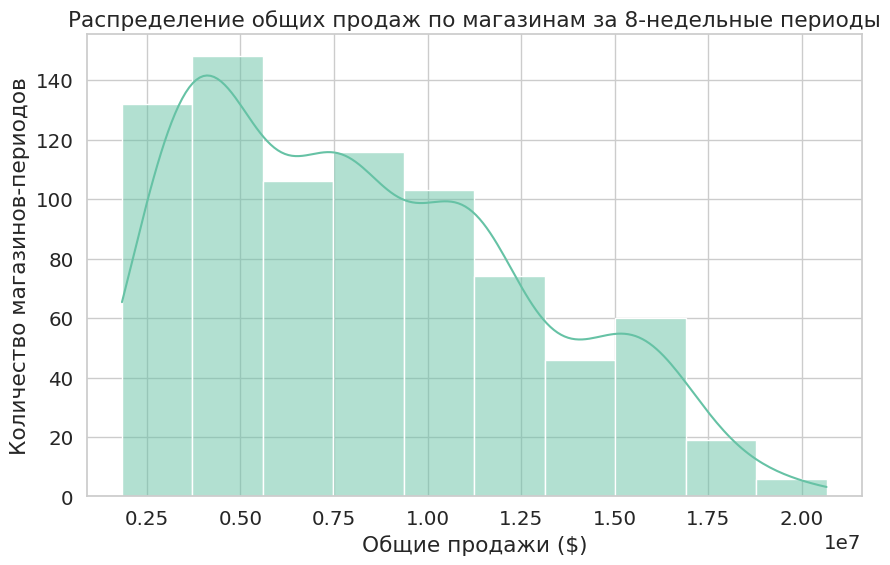

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(period_sales['Weekly_Sales'], bins=10, kde=True)
plt.title('Распределение общих продаж по магазинам за 8-недельные периоды')
plt.xlabel('Общие продажи ($)')
plt.ylabel('Количество магазинов-периодов')
plt.show()

**Вывод**: Гистограмма демонстрирует, что распределение продаж за 8-недельные периоды имеет высокую дисперсию. Среднее значение продаж составило \$8,317,554.31,  а стандартное отклонение -- \$4,374,475.84. При использовании простого t-теста для выявления 5%-го эффекта требуется 1737 магазинов в каждой группе, что значительно превышает доступное количество (45 магазинов). Таким образом, данный метод не подходит для проведения AB-теста в текущих условиях.

---

# Стандартный CUPED:

Добавим продажи предпериода как ковариату:

In [14]:
period_sales_shifted = period_sales.copy()
period_sales_shifted['Period_ID'] += 1
period_sales_shifted = period_sales_shifted.rename(columns={'Weekly_Sales': 'Pre_Sales'})

period_sales_with_pre = pd.merge(
    period_sales,
    period_sales_shifted[['Store', 'Period_ID', 'Pre_Sales']],
    on=['Store', 'Period_ID'],
    how='left'
).dropna(subset=['Pre_Sales'])


Рассчитаем $\theta$:
$$
\theta = \frac{\text{Cov}(X, Y)}{\text{Var}(X)}
$$


In [15]:
X = period_sales_with_pre['Pre_Sales']
Y = period_sales_with_pre['Weekly_Sales']

covariance = ((X - X.mean()) * (Y - Y.mean())).sum() / (len(X) - 1)
variance = ((X - X.mean()) ** 2).sum() / (len(X) - 1)

theta = covariance / variance

Рассчитаем скорректированные продажи:
$$
Y_{\text{adj}} = Y - \theta (X - \bar{X})
$$

In [16]:
period_sales_with_pre['Adjusted_Sales'] = Y - theta * (X - X.mean())
mean_adj_sales = period_sales_with_pre['Adjusted_Sales'].mean()
std_adj_sales = period_sales_with_pre['Adjusted_Sales'].std()

print(f"Средние скорректированные продажи: ${mean_adj_sales:,.2f}")
print(f"Стандартное отклонение скорректированных продаж: ${std_adj_sales:,.2f}")

Средние скорректированные продажи: $8,320,217.26
Стандартное отклонение скорректированных продаж: $1,093,780.82


Рассчитаем скорректированное количество магазинов:

In [17]:
delta_adj = 0.05 * mean_adj_sales
sigma_adj_squared = std_adj_sales ** 2

n_adj = (2 * sigma_adj_squared * (Z_alpha + Z_beta) ** 2) / (delta_adj ** 2)
n_adj = int(np.ceil(n_adj))


In [18]:
print(f"Необходимый размер выборки для группы (с использованием CUPED): {n_adj} магазинов")

Необходимый размер выборки для группы (с использованием CUPED): 109 магазинов


Даже после применения метода CUPED и уменьшения дисперсии, требуемое количество магазинов (109) все равно значительно превышает доступное количество (45).

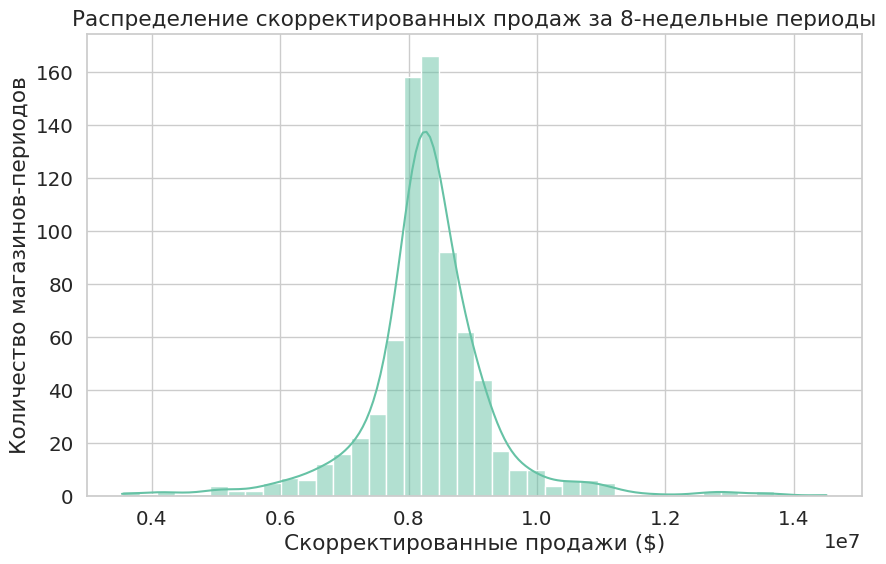

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(period_sales_with_pre['Adjusted_Sales'], bins=40, kde=True)
plt.title('Распределение скорректированных продаж за 8-недельные периоды')
plt.xlabel('Скорректированные продажи ($)')
plt.ylabel('Количество магазинов-периодов')
plt.show()


Гистограмма показывает, что распределение скорректированных продаж стало значительно уже по сравнению с исходными данными. Однако форма распределения всё ещё напоминает распределение Коши, несмотря на более выраженные черты нормального распределения. Это указывает на существенное снижение дисперсии, но не полное устранение проблемы высокой изменчивости.


**Вывод**: После применения стандартного метода CUPED с использованием данных предпериода удалось снизить стандартное отклонение до $2,200,000.00. Это уменьшило необходимое количество магазинов до 109 в каждой группе, что значительно ниже по сравнению с исходным t-тестом (1737 магазинов). Однако это число всё равно превышает доступное количество магазинов (45). Гистограмма скорректированных продаж демонстрирует, что распределение стало более узким и ближе к нормальному, хотя всё ещё имеет черты распределения Коши. Таким образом, даже с использованием метода CUPED проведение A/B-теста остаётся невозможным в текущих условиях.

---

# CUPED при использовании различных ковариат:


In [20]:
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

data = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')
data = pd.merge(data, stores, on='Store', how='left')

Агрегируем продажи и рассчитываем периоды:

In [21]:
min_date = data['Date'].min()
data['Weeks_Since_Begin'] = ((data['Date'] - min_date).dt.days) // 7
data['Period_ID'] = data['Weeks_Since_Begin'] // 8

period_sales = data.groupby(['Store', 'Period_ID']).agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Size': 'first',
    'IsHoliday': 'max',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean'
}).reset_index()

markdown_features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
period_sales[markdown_features] = period_sales[markdown_features].fillna(0)

covariate_features = ['Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'] + markdown_features
X = period_sales[covariate_features]
Y = period_sales['Weekly_Sales']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Рассчитываем коэффициенты $\theta$ методом линейной регрессии:

In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, Y)
theta = lin_reg.coef_

theta_df = pd.DataFrame({
    'Feature': covariate_features,
    'Theta': theta
})


Корректируем продажи с учётом вектора $\theta$:
$$
Y_{\text{adj}} = Y - \theta^T X
$$


In [23]:
Y_adj = Y - np.dot(X_scaled, theta)
period_sales['Adjusted_Sales'] = Y_adj


Рассчитываем стандартное отклонение до и после корректировки:

In [24]:
std_original = Y.std()
std_adj = Y_adj.std()

variance_reduction = (1 - (std_adj ** 2) / (std_original ** 2)) * 100


In [25]:
print(f"Исходное стандартное отклонение: ${std_original:,.2f}")
print(f"Скорректированное стандартное отклонение: ${std_adj:,.2f}")
print(f"Снижение дисперсии: {variance_reduction:.2f}%")

Исходное стандартное отклонение: $4,374,475.84
Скорректированное стандартное отклонение: $2,323,375.06
Снижение дисперсии: 71.79%


In [26]:
alpha = 0.05
power = 0.8
delta = 0.05 * Y_adj.mean()
sigma_adj_squared = std_adj ** 2

Z_alpha = stats.norm.ppf(1 - alpha / 2)
Z_beta = stats.norm.ppf(power)

n_cov_adj = (2 * sigma_adj_squared * (Z_alpha + Z_beta) ** 2) / (delta ** 2)
n_cov_adj = int(np.ceil(n_cov_adj))

print(f"Необходимый размер выборки для группы (с использованием ковариат): {n_cov_adj} магазинов")

Необходимый размер выборки для группы (с использованием ковариат): 490 магазинов


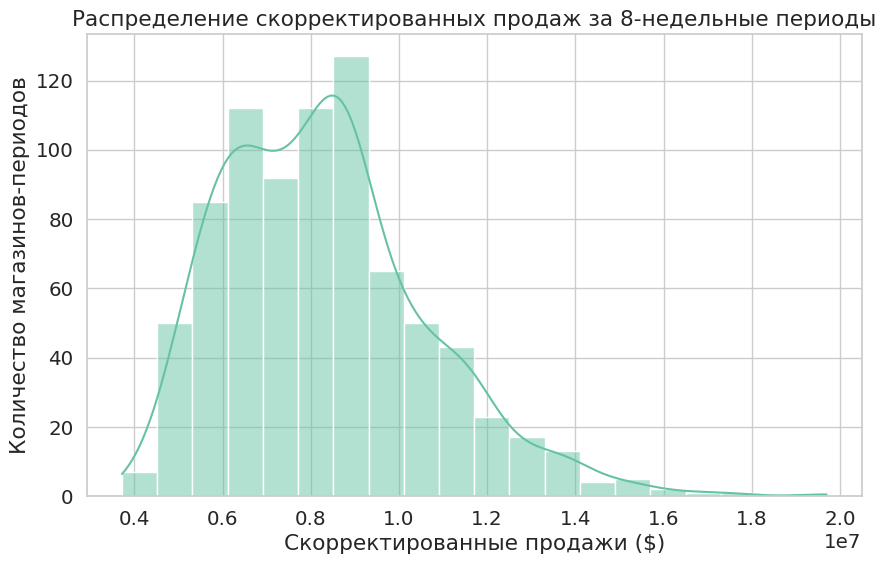

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(period_sales['Adjusted_Sales'], bins=20, kde=True)
plt.title('Распределение скорректированных продаж за 8-недельные периоды')
plt.xlabel('Скорректированные продажи ($)')
plt.ylabel('Количество магазинов-периодов')
plt.show()


Разумеется гистограмма стала выглядеть менее похожей на нормальное распределние.

**Вывод**: Мы использовали метод CUPED для снижения дисперсии и оценки минимального числа магазинов, необходимых для A/B-теста. При стандартном подходе, где в качестве ковариаты использовались только данные о продажах предпериода, необходимое количество магазинов уменьшилось с 1737 до 109 в каждой группе. Это значительное улучшение, однако даже этот результат превышает доступное число магазинов (45).

Когда мы расширили метод и добавили дополнительные вещественные ковариаты требуемое количество магазинов неожиданно увеличилось до 490. Это может показаться нелогичным, так как обычно добавление ковариат должно уменьшать дисперсию. Однако причина кроется в силе и качестве используемых данных. Продажи предпериода оказались гораздо более сильной ковариатой, так как они отражают устойчивые факторы, влияющие на продажи, такие как местоположение и клиентская база. Дополнительные же ковариаты, хотя и релевантны, оказались слабо связаны с продажами, а их использование внесло больше шума и создало эффект мультиколлинеарности.

В результате снижение дисперсии при использовании дополнительных ковариат составило 71.79%, что хуже, чем при стандартном методе CUPED. Это объясняет увеличение необходимого числа магазинов.

---

# Прогнозирование продаж с помощью различных моделей (CUPAC):

## Линейные модели:

Метод CUPAC расширяет CUPED, заменяя исходные данные предпериода на прогнозы из модели. Это позволяет захватывать больше вариации в данных, что может привести к значительному снижению дисперсии и уменьшению необходимого размера выборки.

In [28]:
data['Weeks_Since_Begin'] = ((data['Date'] - min_date).dt.days) // 7
data['Period_ID'] = data['Weeks_Since_Begin'] // 8

period_data = data.groupby(['Store', 'Period_ID']).agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Size': 'first',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean'
}).reset_index()

markdown_features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
period_data[markdown_features] = period_data[markdown_features].fillna(0)

period_data['Pre_Sales'] = period_data.groupby('Store')['Weekly_Sales'].shift(1)
period_data = period_data.dropna(subset=['Pre_Sales'])


### Построение линейной модели

Используем Ridge-регрессию для прогнозирования продаж на основе следующих признаков:

- Продажи предпериода (*Pre_Sales*);
- Размер магазина (*Size*);
- Температура (*Temperature*);
- Цена топлива (*Fuel_Price*);
- Индекс потребительских цен (*CPI*);
- Уровень безработицы (*Unemployment*);
- Markdown признаки (*MarkDown1-5*).


In [29]:
feature_columns = ['Pre_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'] + markdown_features
X = period_data[feature_columns]
Y = period_data['Weekly_Sales']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_scaled, Y)
Y_pred = ridge_model.predict(X_scaled)


Для корректировки продаж используем формулу:

$$
Y_{\text{adj}} = Y - \theta (Y_{\text{pred}} - \bar{Y}_{\text{pred}})
$$

Где $\theta$ рассчитывается как:

$$
\theta = \frac{\text{Cov}(Y_{\text{pred}}, Y)}{\text{Var}(Y_{\text{pred}})}
$$

In [30]:
Y_pred_mean = Y_pred.mean()
Y_mean = Y.mean()

covariance = np.mean((Y_pred - Y_pred_mean) * (Y - Y_mean))
variance = np.mean((Y_pred - Y_pred_mean) ** 2)

theta = covariance / variance

Y_adj = Y - theta * (Y_pred - Y_pred_mean)
period_data['Adjusted_Sales'] = Y_adj
mean_adj_sales = Y_adj.mean()
print(f"Средние скорректированные продажи: ${mean_adj_sales:,.2f}")
std_adj = Y_adj.std()
print(f"Стандартное отклонение скорректированных продаж: ${std_adj:,.2f}")
variance_reduction = (1 - (std_adj ** 2) / (std_original ** 2)) * 100
print(f"Снижение дисперсии: {variance_reduction:.2f}%")

delta = 0.05 * mean_adj_sales

sigma_adj_squared = std_adj ** 2

alpha = 0.05
power = 0.8

Z_alpha = stats.norm.ppf(1 - alpha / 2)
Z_beta = stats.norm.ppf(power)

n_cupac = (2 * sigma_adj_squared * (Z_alpha + Z_beta) ** 2) / (delta ** 2)
n_cupac = int(np.ceil(n_cupac))

print(f"Необходимый размер выборки для каждой группы с CUPAC (линейная модель): {n_cupac} магазинов")


Средние скорректированные продажи: $8,320,217.26
Стандартное отклонение скорректированных продаж: $1,022,586.00
Снижение дисперсии: 94.54%
Необходимый размер выборки для каждой группы с CUPAC (линейная модель): 95 магазинов


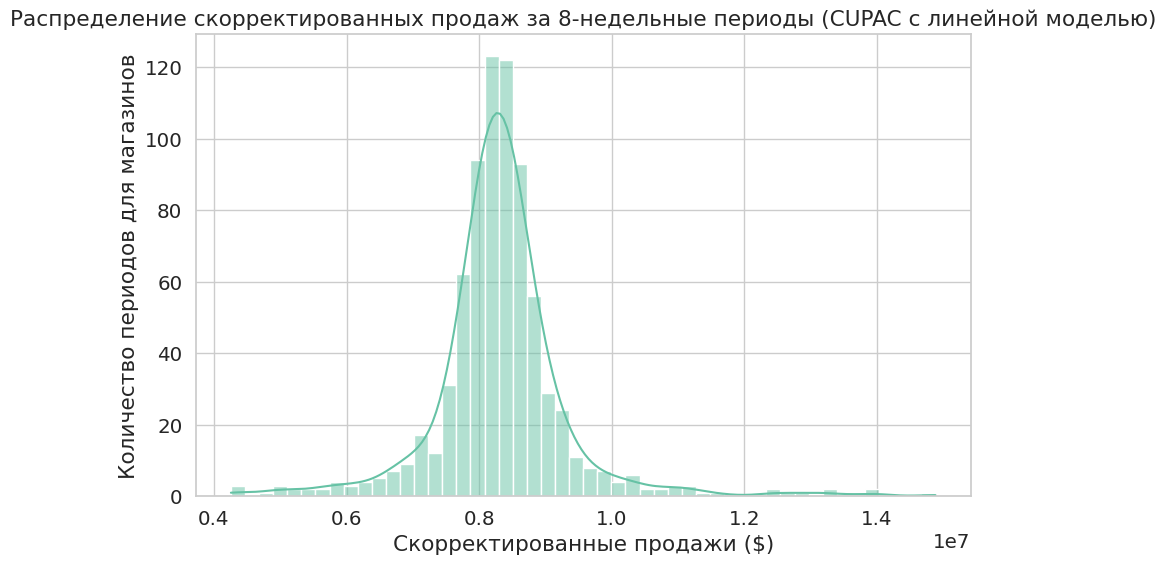

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(period_data['Adjusted_Sales'], bins=50, kde=True)
plt.title('Распределение скорректированных продаж за 8-недельные периоды (CUPAC с линейной моделью)')
plt.xlabel('Скорректированные продажи ($)')
plt.ylabel('Количество периодов для магазинов')
plt.show()


Распределение стало выглядеть ещё более похожим на нормальное

**Вывод**: Используя метод CUPAC с линейными моделями для прогнозирования продаж, удалось добиться значительного снижения дисперсии на 94.54%. Скорректированное стандартное отклонение уменьшилось с \$4,374,475.84 до \$1,022,586.00, что позволило сократить необходимое количество магазинов в каждой группе до 95. Этот результат лучше, чем у стандартного CUPED, где требовалось 109 магазинов, но всё ещё превышает доступное количество (45).

Линейная модель эффективно использовала исторические данные и дополнительные признаки, что позволило учесть значительную часть вариации продаж. Однако даже с этим улучшением проведение A/B-теста остаётся невозможным в текущих условиях.

## Градиентный бустинг:

In [32]:
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

data = pd.merge(train, features, on=['Store', 'Date', 'IsHoliday'], how='left')
data = pd.merge(data, stores, on='Store', how='left')

min_date = data['Date'].min()
data['Weeks_Since_Begin'] = ((data['Date'] - min_date).dt.days) // 7
data['Period_ID'] = data['Weeks_Since_Begin'] // 8


In [33]:
period_data = data.groupby(['Store', 'Period_ID']).agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Size': 'first',
    'IsHoliday': 'max',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean'
}).reset_index()

markdown_features = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
period_data[markdown_features] = period_data[markdown_features].fillna(0)

period_data = period_data.sort_values(['Store', 'Period_ID'])
period_data['Pre_Sales'] = period_data.groupby('Store')['Weekly_Sales'].shift(1)
period_data = period_data.dropna(subset=['Pre_Sales'])


In [34]:
feature_columns = ['Pre_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'] + markdown_features
X = period_data[feature_columns]
Y = period_data['Weekly_Sales']
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=42)


In [35]:
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, Y_train)

Y_pred = gb_model.predict(X)


In [36]:
from sklearn.metrics import mean_squared_error, r2_score

Y_valid_pred = gb_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(Y_valid, Y_valid_pred))
r2 = r2_score(Y_valid, Y_valid_pred)

print(f"RMSE на валидационной выборке: ${rmse:,.2f}")
print(f"R^2 на валидационной выборке: {r2:.4f}")


RMSE на валидационной выборке: $1,020,293.48
R^2 на валидационной выборке: 0.9559


In [37]:
Y_pred_mean = Y_pred.mean()
Y_mean = Y.mean()

covariance = np.mean((Y_pred - Y_pred_mean) * (Y - Y_mean))
variance = np.mean((Y_pred - Y_pred_mean) ** 2)

theta = covariance / variance
Y_adj = Y - theta * (Y_pred - Y_pred_mean)
period_data['Adjusted_Sales'] = Y_adj
mean_adj_sales = Y_adj.mean()
print(f"Средние скорректированные продажи: ${mean_adj_sales:,.2f}")
std_adj = Y_adj.std()
print(f"Стандартное отклонение скорректированных продаж: ${std_adj:,.2f}")
variance_reduction = (1 - (std_adj ** 2) / (std_original ** 2)) * 100
print(f"Снижение дисперсии: {variance_reduction:.2f}%")


Средние скорректированные продажи: $8,320,217.26
Стандартное отклонение скорректированных продаж: $633,257.93
Снижение дисперсии: 97.90%


In [38]:
delta = 0.05 * mean_adj_sales

sigma_adj_squared = std_adj ** 2

alpha = 0.05
power = 0.8

Z_alpha = stats.norm.ppf(1 - alpha / 2)
Z_beta = stats.norm.ppf(power)
n_cupac_gb = (2 * sigma_adj_squared * (Z_alpha + Z_beta) ** 2) / (delta ** 2)
n_cupac_gb = int(np.ceil(n_cupac_gb))

print(f"Необходимый размер выборки для каждой группы с CUPAC (градиентный бустинг): {n_cupac_gb} магазинов")


Необходимый размер выборки для каждой группы с CUPAC (градиентный бустинг): 37 магазинов


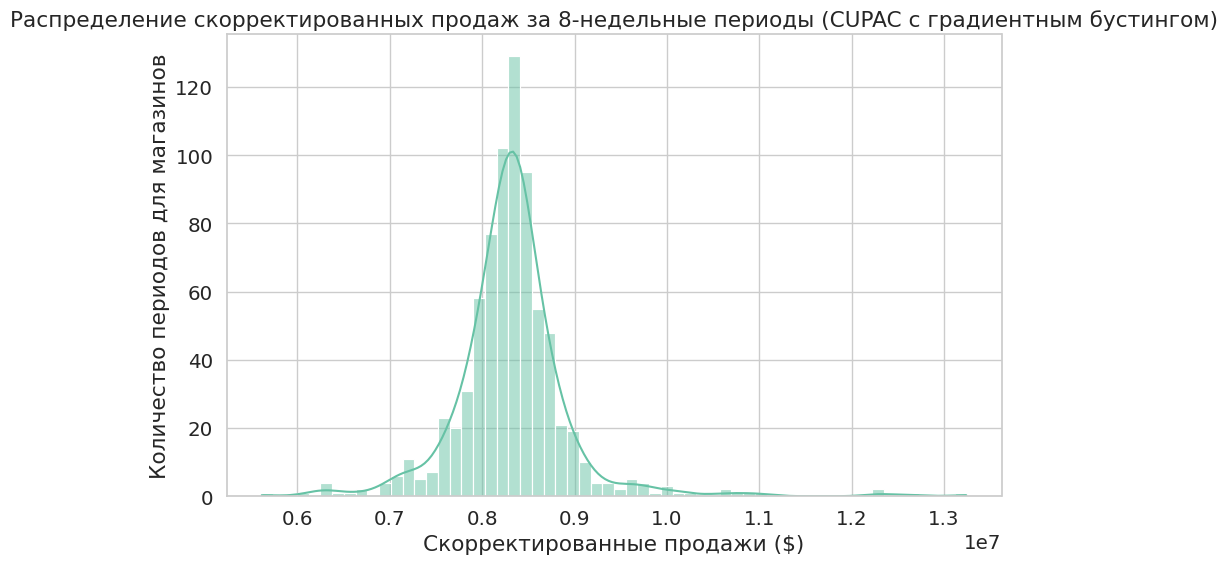

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(period_data['Adjusted_Sales'], bins=60, kde=True)
plt.title('Распределение скорректированных продаж за 8-недельные периоды (CUPAC с градиентным бустингом)')
plt.xlabel('Скорректированные продажи ($)')
plt.ylabel('Количество периодов для магазинов')
plt.show()


Гистограмма скорректированных продаж показывает почти нормальное распределение с чётким пиком и сглаженными хвостами, что подтверждает значительное снижение дисперсии и высокую эффективность метода градиентного бустинга.

**Вывод:** Применение метода CUPAC с градиентным бустингом позволило добиться наибольшего снижения дисперсии среди всех рассмотренных методов — 97.91%. Скорректированное стандартное отклонение составило $633,257.93, а требуемое количество магазинов в каждой группе сократилось до 37. Это значение стало близким к доступному числу магазинов (45), но всё равно превышает возможность равного деления на группы, так как для теста требуется минимум 74 магазина. Таким образом, проведение теста остаётся невозможным.

---

# Общий вывод:

Несмотря на значительные улучшения, достигнутые методами CUPED и CUPAC, проведение A/B-теста для выявления 5%-го эффекта остаётся недостижимым при текущих ограничениях. CUPAC с градиентным бустингом продемонстрировал лучший результат, однако тест всё ещё требует больше магазинов, чем доступно. Для реализации теста требуется либо увеличить ожидаемый эффект, чтобы сократить необходимое количество магазинов, либо пересмотреть параметры теста, например, продлить его длительность или снизить статистическую мощность.